##### This notebook 

##### ../scripts/1_Fit_GP_model.py
##### ../scripts/2_yeast_marginals_cli.py
##### ../scripts/3_yeast_get_pos_marginals_batched-cli.py

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import sys
import importlib

import os
os.environ['CUDA_PATH'] = '/apps/compilers/cuda/13.2.1' 

import torch
print(f"number of available GPUs = {torch.cuda.device_count()}")
output_device = 'cpu'


import vcme
from vcme.functions import prepare_proteingym_data
from vcme.utils import yeast_data, clear_gpu_mem, reload_obj, get_pathway_info
from vcme.utils import tensor_scatter, read_marginal_results, get_gene_interval

from epik.utils import encode_seqs, split_training_test

import epikVC
from epikVC.models import GPModel, make_GP_model, load_GP_model

number of available GPUs = 1


In [2]:
fig_path = '../figures/yeast/'
result_path = '../results/yeast_analysis/5_19/'
# load model fitted using "scripts/get_GP_37C_pruned_snps.py"

# checkpoint_path = '../model_checkpoints/37C_r2_threshold=0.995_MAF_threshold=0/'
checkpoint_path = '../model_checkpoints/37C_r2_threshold=None_MAF_threshold=0/'

geno_path = "/orange/juannanzhou/MarginalEpistasis/data/"
pheno_path = "/orange/juannanzhou/dryad_data/"
out_path = '../results/yeast_analysis/' 
pheno_name = '37C'
model_name = 'GP_model_k=8.model'

In [3]:
# data = yeast_data(geno_path, pheno_path, pheno_name, output_device, prune_snps=True, r2_threshold=0.995, maf_threshold=0)
data = yeast_data(geno_path, pheno_path, pheno_name, output_device, prune_snps=False, r2_threshold=None, maf_threshold=0)
# pruned_loci = data.loci_pruned

Loading yeast dataset
Using all snps
Finished loading


In [4]:
from vcme.utils import YeastMetadata

snp_info_path = "../data/yeast/snp_info_final.csv"
pathway_info_path = "/blue/juannanzhou/fahimeh.rahimi/Marginal_Epistasis/yeast_pathway_gene_tables/all_pathway_gene_tables.tsv"

genomic_meta_data = YeastMetadata(snp_info_path, pathway_info_path)

snp_info = genomic_meta_data.snp_info
gene_info = genomic_meta_data.gene_info

genes = snp_info.gene_standard_name.unique()
print(len(genes))

gene_snps = {}

for g in genes:
    snps = snp_info.index[snp_info.gene_standard_name == g]
    gene_snps[g] = snps

number of pathways = 123
number of genes in pathways = 355
4931


## Marginal epistasis analysis

In [6]:
# Run ../scripts/2_yeast_marginals_cli.py on Slurm to get the marginal epistasis 

result_path = '../results/yeast_analysis/8_31/'

env = '37C'

marginals_add = read_marginal_results(result_path + f"yeast_marginals_k=1_env={env}.csv")

marginals_k2 = read_marginal_results(result_path + f"yeast_marginals_k=2_env={env}.csv")

marginals_k3 = read_marginal_results(result_path + f"yeast_marginals_k=3_env={env}.csv")

### Site marginals

rescale vc to percentage
rescale vc to percentage
rescale vc to percentage


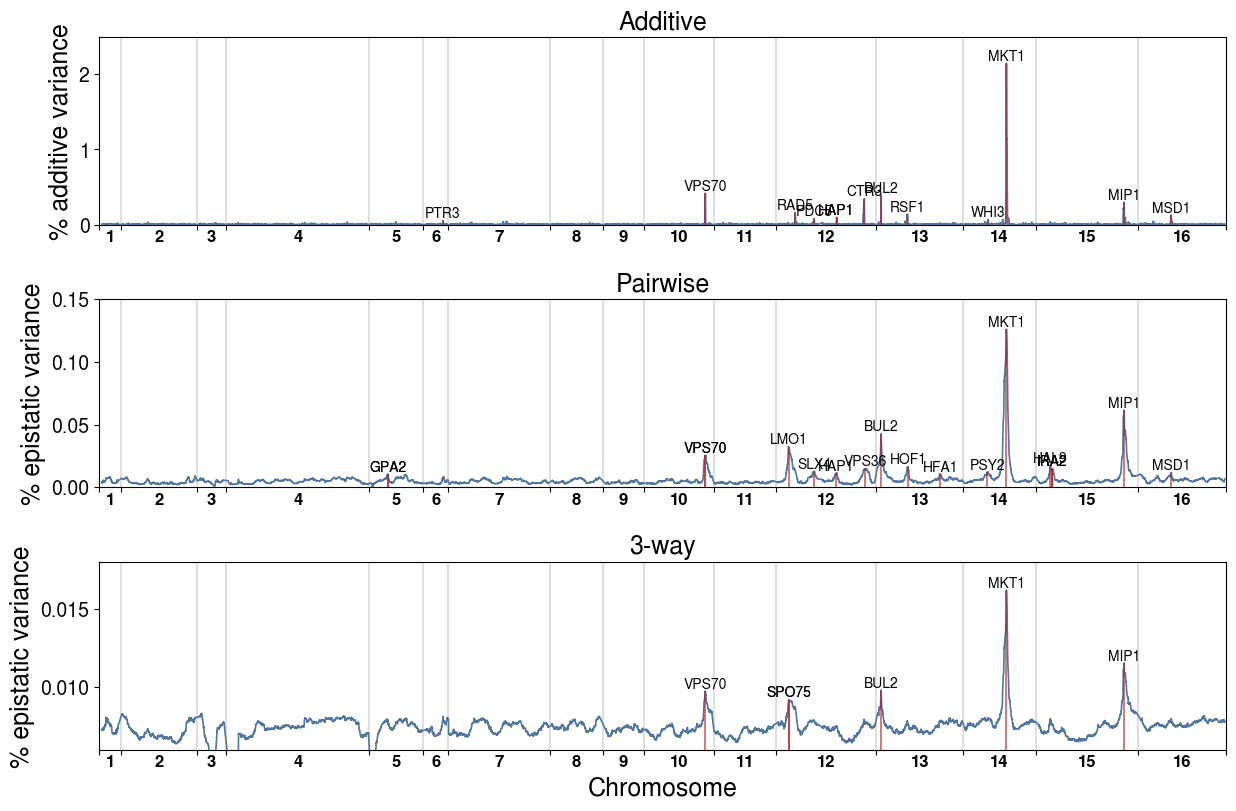

In [9]:
import vcme.utils
importlib.reload(vcme.utils)
from vcme.utils import make_man, make_df_plot, plot_track


from vcme.utils import get_maf

MAF = get_maf(data.geno_t)

sub = np.where(MAF > 0.10)[0] # only visualize SNPs with MAF above threshold


plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Nimbus Sans"],
    }
)


# Create a figure with 2 rows, 1 column
fig, (ax_top, ax_mid, ax_bottom) = plt.subplots(3, 1, figsize=(14, 8), constrained_layout=True)
fig.get_layout_engine().set(hspace=0.1)


# Call the function for both datasets using the provided axes
plot_df = marginals_add
plot_df /= plot_df.sum()
y_threshold = 100 * plot_df.effect.quantile(.996)
make_man(plot_df, genomic_meta_data.snp_info, y_threshold, 
         ylab='% additive variance', label_genes=True, ax=ax_top, title='Additive', label_x_axis=False, 
         ylim=[0.00, 2.5], 
         shade_chromosomes=False, 
         peak_line_mode="track", 
        chromosome_ticks="boundaries",
        chromosome_linewidth=1.5, 
        chromosome_linealpha=0.25)

plot_df = marginals_k2
plot_df /= .5 * plot_df.sum() # normalized to sum to 1
y_threshold = 100 * plot_df.effect.quantile(.95)

make_man(plot_df, genomic_meta_data.snp_info, y_threshold, 
         ylab='% epistatic variance', label_genes=True, ax=ax_mid, title='Pairwise', 
         label_x_axis=False, 
         ylim=[0, 0.15], 
         shade_chromosomes=False, 
         peak_line_mode="track", 
        chromosome_ticks="boundaries",
        chromosome_linewidth=1.5, 
        chromosome_linealpha=0.25)


plot_df = marginals_k3
plot_df /= 1/3 * plot_df.sum() # normalized to sum to 1
plot_df = plot_df.iloc[sub]
y_threshold = 100 * plot_df.effect.quantile(.98)

make_man(plot_df, genomic_meta_data.snp_info, y_threshold, 
         ylab='% epistatic variance', label_genes=True, ax=ax_bottom, title='3-way', 
         shade_chromosomes=False, 
         ylim=[0.006, 0.018], 
         peak_line_mode="track", 
        chromosome_ticks="boundaries",
        chromosome_linewidth=1.5, 
        chromosome_linealpha=0.25)

plt.savefig(fig_path + f'Manhattan_plot_{env}.pdf')

plt.show()

### Zoom to Epistatic QTLs

In [10]:
marginals_k2 /= .5 * marginals_k2.sum()

In [11]:
import vcme.utils
importlib.reload(vcme.utils)
from vcme.utils import make_man, make_df_plot, plot_track

rescale vc to percentage


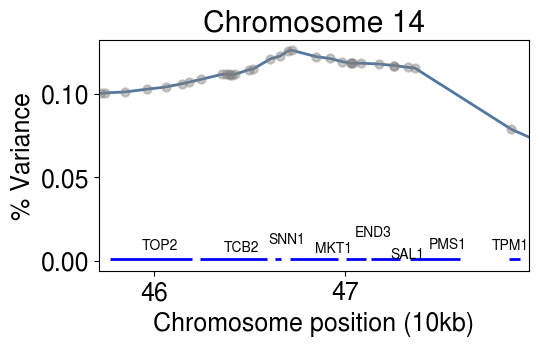

In [12]:
y_threshold = 0.01 * 0.1
pad = 10000

gene = 'MKT1'
chrom, lower, upper = get_gene_interval(gene, gene_info)

lower, upper = lower - pad, upper + pad

plot_track(marginals_k2, snp_info, gene_info, y_threshold, 'effect', 
           ylab='% Variance', chrom=chrom, chrom_range=[lower, upper])

plt.savefig(fig_path + f"qtl_{env}_gene={gene}.pdf")
plt.show()

rescale vc to percentage


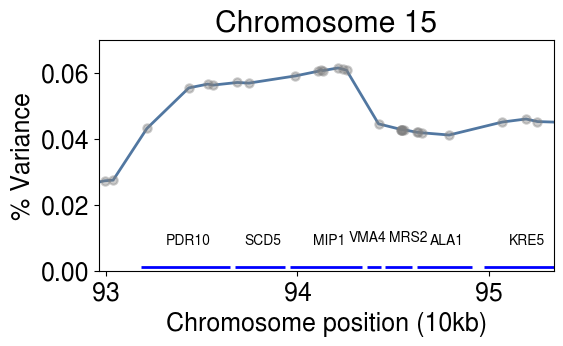

In [26]:
y_threshold = 0.01 * 0.1
pad = 10000

gene = 'MIP1'
chrom, lower, upper = get_gene_interval(gene, gene_info)

lower, upper = lower - pad, upper + pad

plot_track(marginals_k2, snp_info, gene_info, y_threshold, 'effect', 
           ylab='% Variance', chrom=chrom, chrom_range=[lower, upper], ylim=[0, 0.07])

plt.savefig(fig_path + f"qtl_{env}_gene={gene}.pdf")
plt.show()

rescale vc to percentage


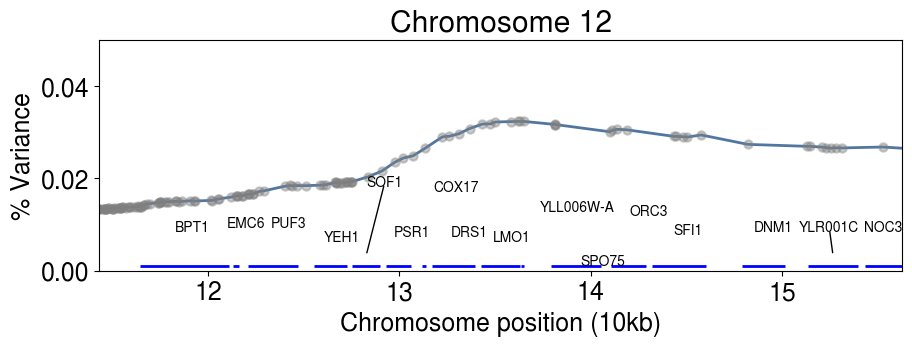

In [25]:
y_threshold = 0.01 * 0.1
pad = 20000

gene = 'LMO1'
chrom, lower, upper = get_gene_interval(gene, gene_info)

lower, upper = lower - pad, upper + pad

plot_track(marginals_k2, snp_info, gene_info, y_threshold, 'effect', 
           ylab='% Variance', chrom=chrom, chrom_range=[lower, upper], ylim=[0, 0.05])

plt.savefig(fig_path + f"qtl_{env}_gene={gene}.pdf")

plt.show()

rescale vc to percentage


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


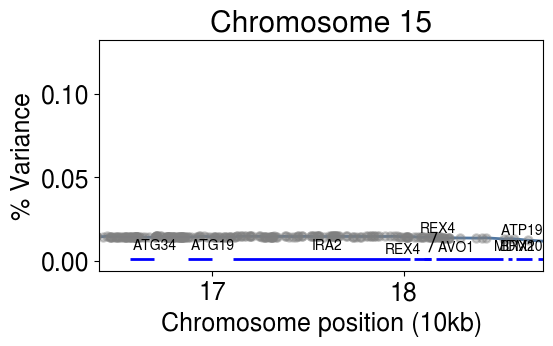

In [15]:
y_threshold = 0.01 * 0.1
pad = 7000

gene = 'IRA2'
chrom, lower, upper = get_gene_interval(gene, gene_info)

lower, upper = lower - pad, upper + pad

plot_track(marginals_k2, snp_info, gene_info, y_threshold, 'effect', 
           ylab='% Variance', chrom=chrom, chrom_range=[lower, upper])

plt.savefig(fig_path + f"qtl_{env}_gene={gene}.pdf")

plt.show()

rescale vc to percentage


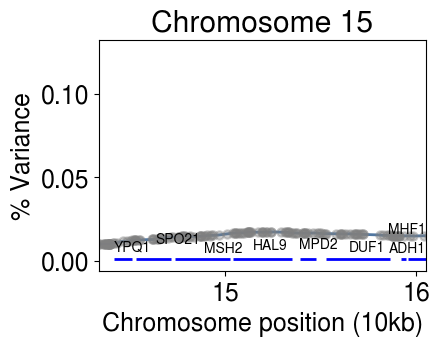

In [16]:
y_threshold = 0.01 * 0.1
pad = 7000

gene = 'HAL9'
chrom, lower, upper = get_gene_interval(gene, gene_info)

lower, upper = lower - pad, upper + pad

plot_track(marginals_k2, snp_info, gene_info, y_threshold, 'effect', 
           ylab='% Variance', chrom=chrom, chrom_range=[lower, upper])

plt.savefig(fig_path + f"qtl_{env}_gene={gene}.pdf")

plt.show()

rescale vc to percentage
ERROR! Session/line number was not unique in database. History logging moved to new session 8903


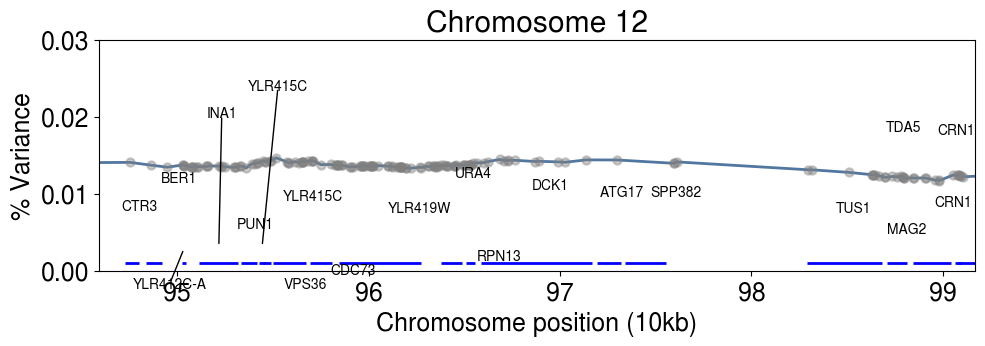

In [23]:
y_threshold = 0.01 * 0.1
pad = 20000

gene = 'DCK1'
chrom, lower, upper = get_gene_interval(gene, gene_info)

lower, upper = lower - pad, upper + pad

plot_track(marginals_k2, snp_info, gene_info, y_threshold, 'effect', 
           ylab='% Variance', chrom=chrom, chrom_range=[lower, upper], ylim=[0, .03])

plt.savefig(fig_path + f"qtl_{env}_gene={gene}.pdf")

plt.show()

rescale vc to percentage


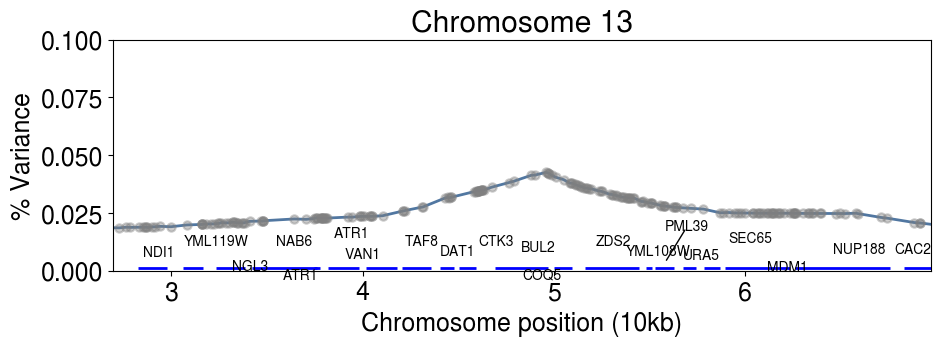

In [28]:
y_threshold = 0.01 * 0.1
pad = 20000

gene = 'BUL2'
chrom, lower, upper = get_gene_interval(gene, gene_info)

lower, upper = lower - pad, upper + pad

plot_track(marginals_k2, snp_info, gene_info, y_threshold, 'effect', 
           ylab='% Variance', chrom=chrom, chrom_range=[lower, upper], ylim=[0, .1])

plt.savefig(fig_path + f"qtl_{env}_gene={gene}.pdf")

plt.show()

rescale vc to percentage


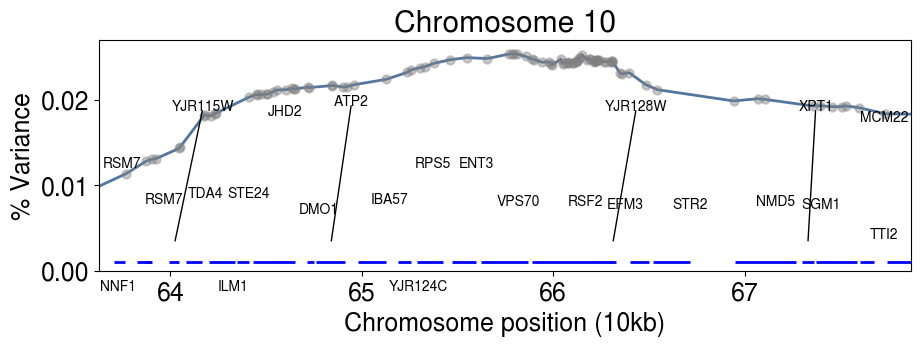

In [30]:
y_threshold = 0.01 * 0.1
pad = 20000

gene = 'VPS70'
chrom, lower, upper = get_gene_interval(gene, gene_info)

lower, upper = lower - pad, upper + pad

plot_track(marginals_k2, snp_info, gene_info, y_threshold, 'effect', 
           ylab='% Variance', chrom=chrom, chrom_range=[lower, upper], ylim=[0, .027])

plt.savefig(fig_path + f"qtl_{env}_gene={gene}.pdf")

plt.show()